In [8]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *
from src.experiments import *

import matplotlib.pyplot as plt
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Lotka-Volterra

In [9]:
lotka_volterra_rhs = generate_lotka_volterra_rhs(*default_params['lotka_volterra'])
true_coeffs = generate_lotka_volterra_true_coefficients(*default_params['lotka_volterra'])
x0 = default_x0['lotka_volterra']

dts = np.logspace(-2, 0, 11).tolist()
train_interpolation_dts = np.logspace(-3, -1, 11).tolist()[:-1] + [None]

t_span = (0, 50)
t_span_train = (0, 20)

noise_level = 0.05

experiment_config = {
    # define fixed parameters
    'rhs': lotka_volterra_rhs,
    'derivative_approximation': dxdt_finite_difference,
    't_eval_test': np.arange(t_span[0], t_span[1] + 0.01, 0.01),
    'np_seed': 42,
    'true_coeffs': true_coeffs,
    # define parameters that can be lists
    'x0': x0, 'noise_level': noise_level,
    'train_interpolation_dt': train_interpolation_dts,
    't_eval_train': None, 'dt_train': dts, 't_span_train': t_span_train,
    'threshold': 0.05, 'poly_order': 5, 'n_frequencies': 0
}

results = run_experiment(experiment_config, generate_prediction=True)

rows are train_interpolation_dt. there are 11 rows.
columns are dt_train. there are 11 columns.
step 1 of 11


100%|██████████| 11/11 [00:03<00:00,  2.85it/s]


step 2 of 11


 82%|████████▏ | 9/11 [00:02<00:00,  3.60it/s]c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Repeated error test failures (internal error).
  solver._y, solver.t = integrator.run(
100%|██████████| 11/11 [00:03<00:00,  3.14it/s]


step 3 of 11


...

100%|██████████| 11/11 [00:05<00:00,  1.94it/s]


step 10 of 11


100%|██████████| 11/11 [00:05<00:00,  2.02it/s]


step 11 of 11


100%|██████████| 11/11 [00:04<00:00,  2.68it/s]


rows are train_interpolation_dt. there are 11 rows.
columns are dt_train. there are 11 columns.


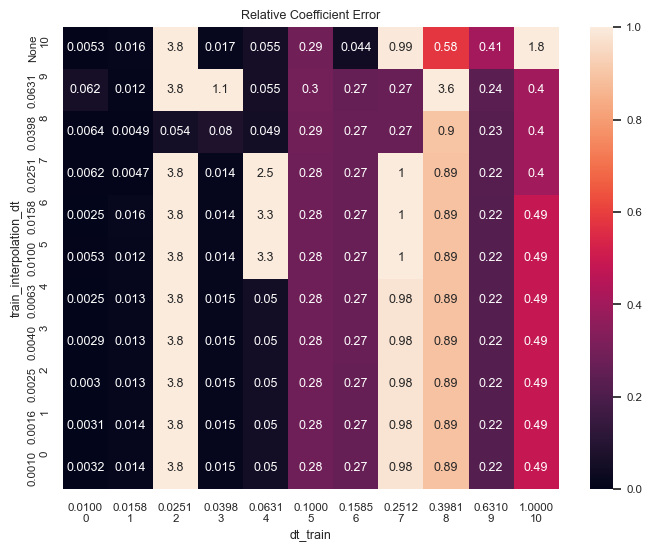

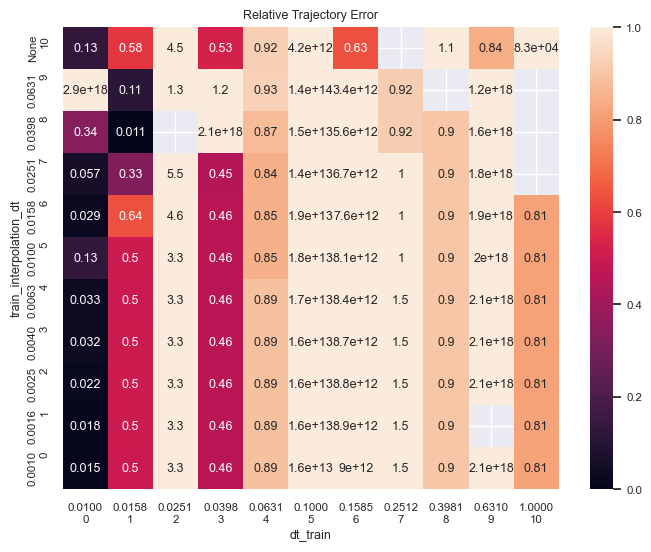

In [10]:
plot_heatmaps(experiment_config, results)

x0' = + 1.05390 x0 + -0.37145 x0 x1 
x1' = + -1.01478 1 + 0.28398 x0 + -0.07216 x1 


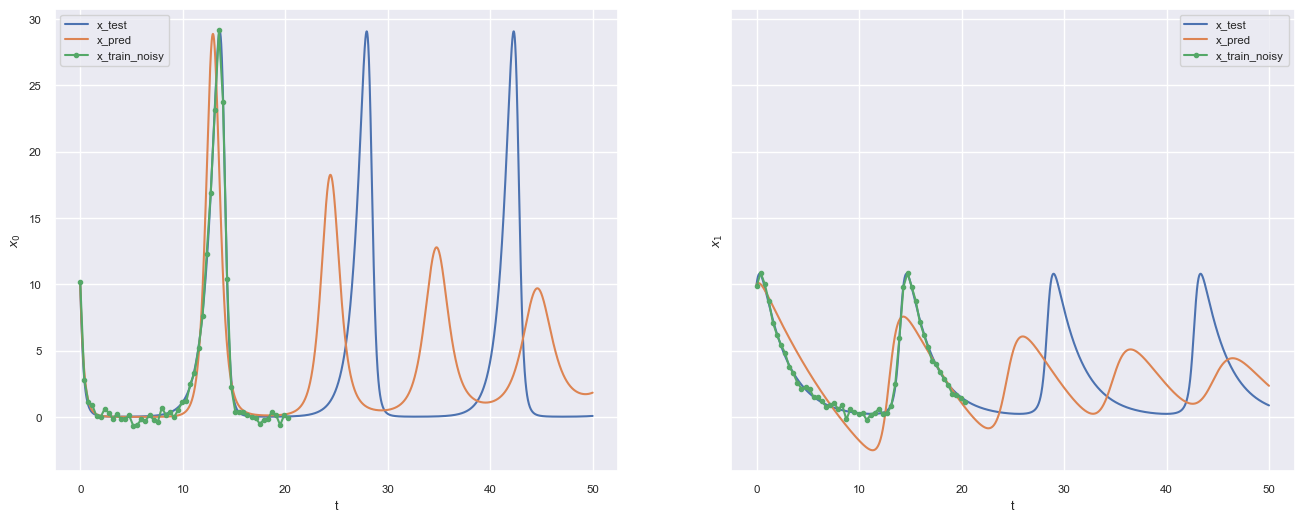

In [11]:
display_single_result(experiment_config, results, 8, 6, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])

# Other System

In [12]:
# duffing_oscillator_rhs = generate_duffing_oscillator_rhs(*default_params['duffing_oscillator'])
# true_coeffs = generate_duffing_oscillator_true_coefficients(*default_params['duffing_oscillator'])
# x0 = default_x0['duffing_oscillator']

# dt = 0.2

# train_interpolation_dts = np.logspace(-3, np.log10(dt), 11).tolist()[:-1] + [None]
# noise_levels = np.logspace(-3, 0, 10).tolist()

# t_span = (0, 50)
# t_span_train = (0, 15)

# experiment_config2 = {
#     # define fixed parameters
#     'rhs': duffing_oscillator_rhs,
#     'derivative_approximation': dxdt_finite_difference,
#     't_eval_test': np.arange(t_span[0], t_span[1] + 0.01, 0.01),
#     'np_seed': 0,
#     'true_coeffs': true_coeffs,
#     # define parameters that can be lists
#     'x0': x0, 'noise_level': noise_levels,
#     't_eval_train': None, 'dt_train': dt, 't_span_train': t_span_train,
#     'train_interpolation_dt': train_interpolation_dts,
#     'threshold': 0.05, 'poly_order': 5, 'n_frequencies': 0
# }

# results2 = run_experiment(experiment_config2, generate_prediction=True)

In [13]:
# plot_heatmaps(experiment_config2, results2)

In [14]:
# display_single_result(experiment_config2, results2, 7, 3, keys_to_display=['x_test', 'x_pred', 'x_train_noisy'])